### Objetivos do Notebook

Notebook reponsável por extrair as tabelas de origem do datamart de STI armazenadas na API SGT e salvar esses dados no formato Parquet no bucket bronze do MinIO.

### Data Owner
Rodrigo Souza - rodrigo.souza@sfiemt.ind.br


### Origens extraídas do SGT
As seguintes tabelas serão extraídas da API SGT:

- **sti_atendimentos_integracoes_sgt**

### Local de destino no bucket bronze
Os datasets resultantes gerados pela extração do notebook serão armazenados no bucket bronze do MinIO no formato Parquet, seguindo a estrutura de diretórios e nomes de arquivos baseados na data de execução do notebook.

- **sti_atendimentos_integracoes_sgt:** bronze/sti/apisgt/sti_atendimentos_integracoes_sgt/{data_execucao}/sti_atendimentos_integracoes_sgt_{data_execucao}.parquet

### Linhagem de dados
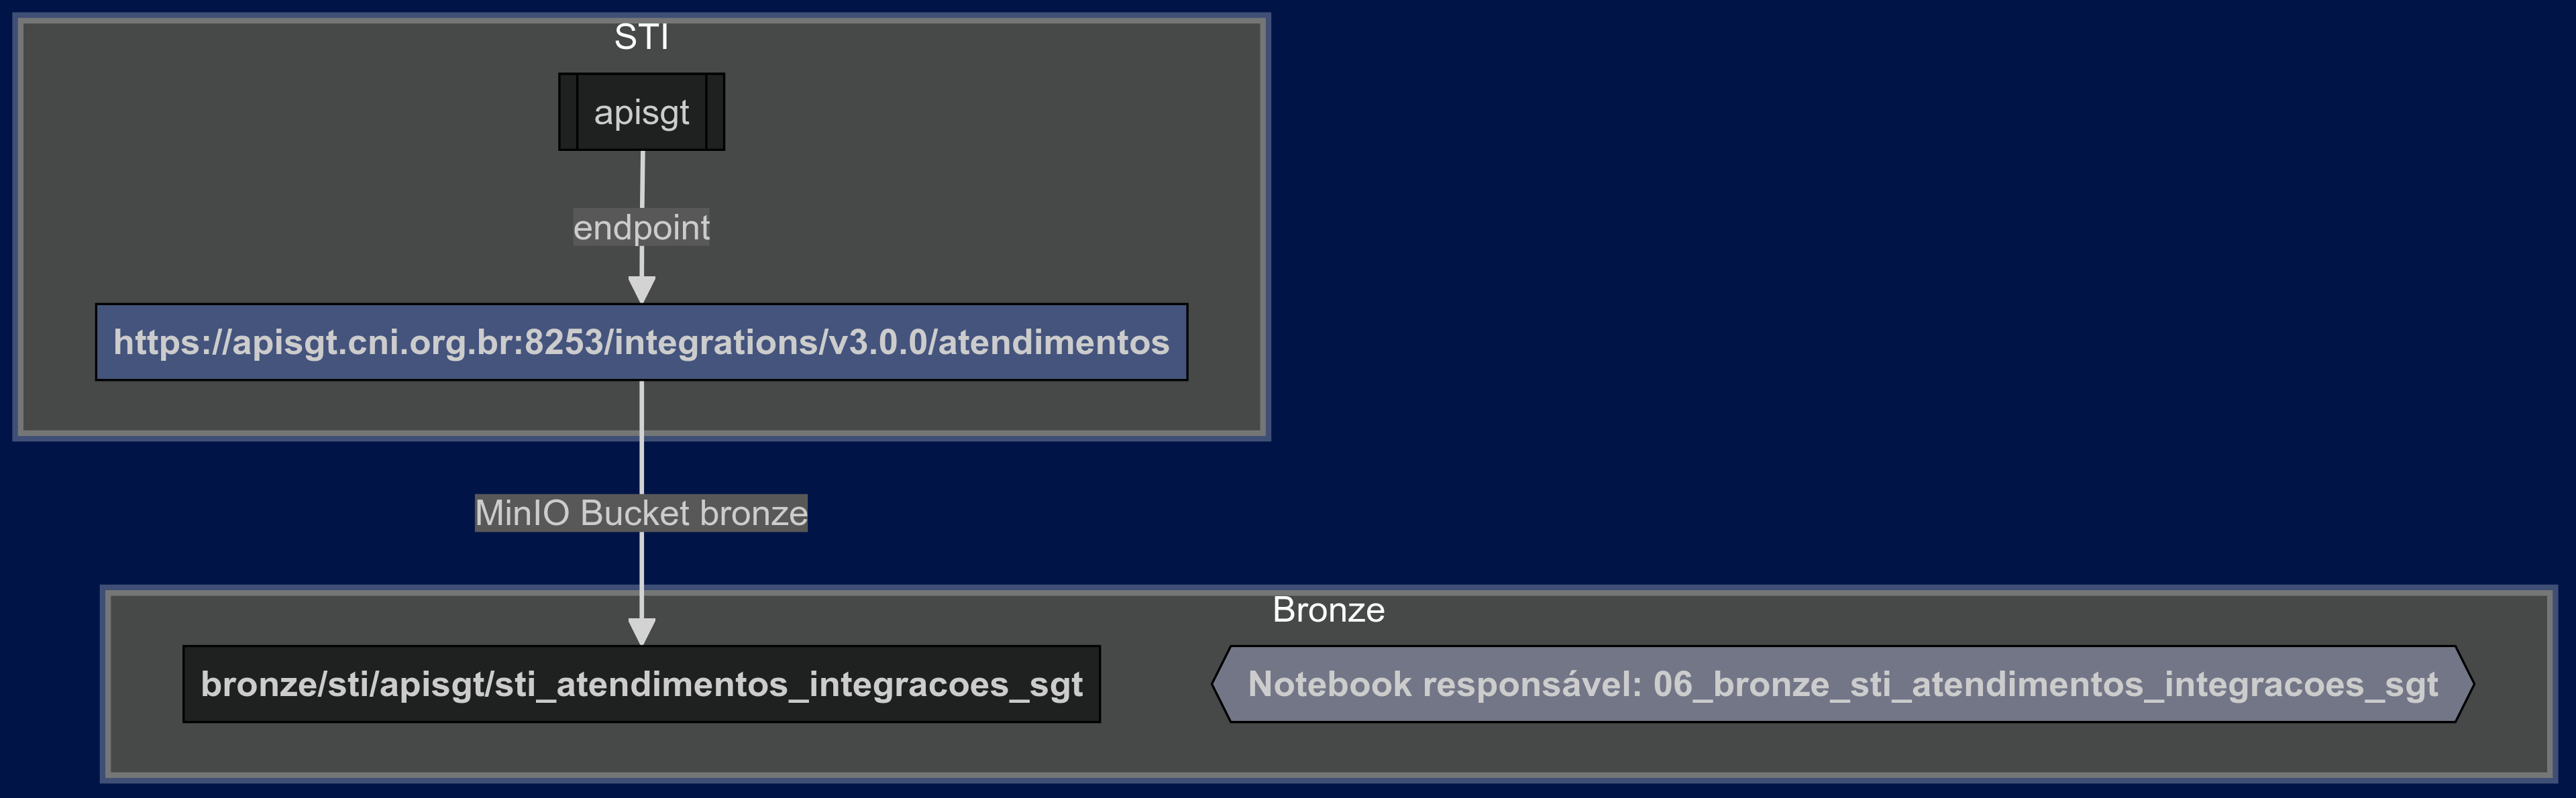

# Bibliotecas necessárias

In [1]:
import os
from pyspark.sql import SparkSession
from datetime import datetime, timedelta
from crawler_sti import create_df,insert_datalake

tabela = 'sti_atendimentos_integracoes_sgt'
endpoint = 'https://apisgt.cni.org.br:8253/integrations/v3.0.0/atendimentos'

# Cricação da variáveis necessárias

In [2]:
#Último x dias
#dias = 5
#start_date = datetime.now() - timedelta(days=dias)
#date = start_date.strftime('%Y%m%d')

# Data Atul
#date_now = datetime.now().strftime('%Y%m%d')

#Data específica
date = '20230101'

# Extração

In [3]:
df = create_df(endpoint, date, tabela)

Erro ao tentar acessar a API: HTTPSConnectionPool(host='apisgt.cni.org.br', port=8253): Max retries exceeded with url: /integrations/v3.0.0/atendimentos?dataInicio=20230101 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7f23b0099350>, 'Connection to apisgt.cni.org.br timed out. (connect timeout=None)'))


# Gravação no datalake

In [4]:
insert_datalake(df, tabela)

Removendo arquivos do Bucket
Enviando sti_atendimentos_integracoes_sgt para o Bucket bronze do minIO


AttributeError: 'NoneType' object has no attribute 'write'